### 使用pandas读入并处理数据

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn


train_data = pd.read_csv(r'E:\Pycharm\d2l\data\train.csv')

test_data = pd.read_csv(r'E:\Pycharm\d2l\data\test.csv')

print(train_data.shape)
print(test_data.shape)  

(1460, 81)
(1459, 80)


### 前四个和最后两个特征，以及相应标签（房价）

In [3]:
print(train_data.iloc[0:4,[0,1,2,3,-3,-2,-1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


### 在每个样本中，第一个特征是ID，我们将其从数据集中删除

In [4]:
all_features = pd.concat((train_data.iloc[:, 1:-1], test_data.iloc[:, 1:]))

### 将所有缺失值替换为相应特征的评价值。通过将特征重新缩放到平均值和单位方差来标准化数据

In [12]:
numeric_features = all_features.dtypes[all_features.dtypes != 'object'].index
all_features[numeric_features] = all_features[numeric_features].apply(lambda x: (x - x.mean()) / (x.std()))
all_features[numeric_features] = all_features[numeric_features].fillna(0)

### 处理离散值。我们用一次独热编码替换他们

In [16]:
all_features = pd.get_dummies(all_features, dummy_na = True)
all_features = all_features.astype('float32')
print(all_features.shape)

(2919, 330)


### 从pandas格式中提取numpy格式，并将其转换为张量表示

In [33]:
n_train = train_data.shape[0]
train_features = torch.tensor(all_features[:n_train].values)
test_features = torch.tensor(all_features[n_train:].values)
train_labels = torch.tensor(train_data.SalePrice.values.astype(np.float32)).view(-1, 1)

### 训练

In [34]:
loss = nn.MSELoss()
in_features = train_features.shape[1]

def get_net():
    net = nn.Sequential(nn.Linear(in_features, 1))
    return net


### 我们更关心相对误差，解决这个问题的一种方法是用价格预测的对数来衡量差异

In [35]:
def log_rmse(net, features, labels):
    with torch.no_grad():
        clipped_preds = torch.max(net(features), torch.tensor(1.0))
        rmse = torch.sqrt(loss(clipped_preds.log(), labels.log()))
    return rmse.item()

### 我们的训练将借助Adam优化器

In [36]:
def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate, weight_decay, batch_size):
    train_ls, test_ls = [], []
    optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate, weight_decay = weight_decay)
    for epoch in range(num_epochs):
        net.train()
        optimizer.zero_grad()
        l = loss(net(train_features), train_labels)
        l.backward()
        optimizer.step()
        net.eval()
        train_ls.append(log_rmse(net, train_features, train_labels))
        if test_labels is not None:
            test_ls.append(log_rmse(net, test_features, test_labels))
    return train_ls, test_ls

### K折交叉验证

In [37]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat([X_train, X_part], dim = 0)
            y_train = torch.cat([y_train, y_part], dim = 0)
    return X_train, y_train, X_valid, y_valid

### 返回训练和验证误差的平均值

In [41]:
def k_fold(k, X_train, y_train, num_epochs, learning_rate, weight_decay, batch_size):
    train_l_sum, valid_l_sum = 0, 0
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net = get_net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size)
        train_l_sum += train_ls[-1]
        valid_l_sum += valid_ls[-1]
        if i == 0:
            plt.figure(figsize=(4.5, 3))  # 单独设置画布大小
            plt.plot(list(range(1, num_epochs + 1)), train_ls, label='train')
            plt.plot(list(range(1, num_epochs + 1)), valid_ls, label='valid')
            plt.xlabel('epoch')
            plt.ylabel('rmse')
            plt.xlim([1, num_epochs])
            plt.legend()
            plt.show()  
    return train_l_sum / k, valid_l_sum / k

### 模型选择

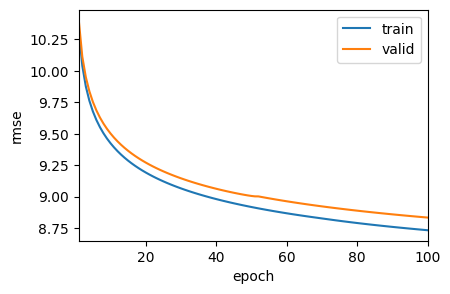

5-fold validation: avg train rmse: 8.7520, avg valid rmse: 8.9395


In [45]:
k, num_epochs, lr, weight_decay, batch_size = 5, 100, 1, 0, 64
train_l, valid_l = k_fold(k, train_features, train_labels, num_epochs, lr, weight_decay, batch_size)
print(f'{k}-fold validation: avg train rmse: {train_l:.4f}, avg valid rmse: {valid_l:.4f}')

### 提交你的kaggle预测

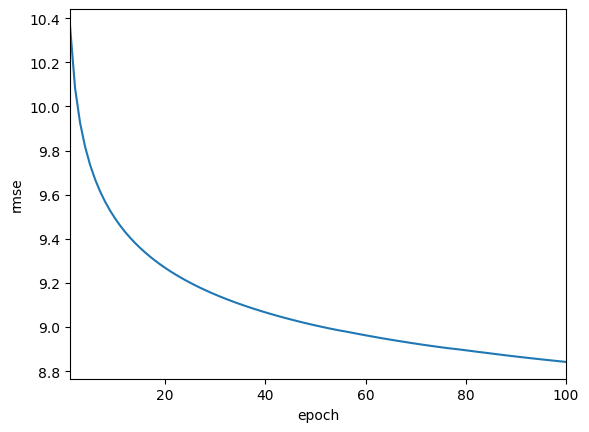

In [46]:
def train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size):
    net = get_net()
    train_ls, _ = train(net, train_features, train_labels, None, None, num_epochs, lr, weight_decay, batch_size)
    plt.plot(list(range(1, num_epochs + 1)), train_ls)
    plt.xlabel('epoch')
    plt.ylabel('rmse')
    plt.xlim([1, num_epochs])
    plt.show()
    net.eval()
    preds = net(test_features).detach().numpy()
    test_data['SalePrice'] = pd.Series(preds.reshape(1,-1)[0])
    submission = test_data[['Id', 'SalePrice']]
    submission.to_csv('submission.csv', index = False)

train_and_pred(train_features, test_features, train_labels, test_data, num_epochs, lr, weight_decay, batch_size)
